# CTA Pipeline — Dry Run

Quick end-to-end smoke test for **pretraining** and **fine-tuning**.

All cells run from the **UTUEL repo root** — make sure the kernel working directory is set there.

```
Stage 1 — Pretrain  : TableEmbedJePA on CTA data (SMP regime)
Stage 2 — Finetune  : multi-label column type classifier
```

In [5]:
import os, sys
from pathlib import Path

# ── Ensure we run from the repo root ─────────────────────────────────────────
REPO_ROOT = Path("__file__").resolve().parent.parent  # CTA/../
if not (REPO_ROOT / "CTA").exists():
    # Fallback: assume notebook is already opened from repo root
    REPO_ROOT = Path.cwd()
os.chdir(REPO_ROOT)
print(f"Working directory: {Path.cwd()}")

# Add repo root + TRL-model to path so imports resolve
for p in [str(REPO_ROOT), str(REPO_ROOT / "TRL-model")]:
    if p not in sys.path:
        sys.path.insert(0, p)

Working directory: C:\Users\wtchuitc\Documents\GitHub\UTUEL


## 1 — Shared Hydra overrides for a fast dry run

These CLI flags cap records/rows/epochs so the whole notebook completes in seconds.

In [1]:
# Override flags appended to every %run command
DRY = (
    "data.max_records=20 "
    "data.max_rows_train=5 "
    "data.max_rows_dev=1 "
    "data.max_rows_test=1 "
	"data.folder=D:\\TABLE_DATASET\\HYTREL\\ckpt_data\\ckpt_data\\data\\col_ann "
    "pretraining.epochs=10 "
    "pretraining.batch_size=4 "
    "finetuning.epochs=10 "
    "finetuning.batch_size=4 "
    "pretraining.dataloader_num_workers=0 "
    "finetuning.dataloader_num_workers=0 "
    "embedder.cache_embeddings=true "
)
print("Dry-run overrides:", DRY)


Dry-run overrides: data.max_records=20 data.max_rows_train=5 data.max_rows_dev=1 data.max_rows_test=1 data.folder=D:\TABLE_DATASET\HYTREL\ckpt_data\ckpt_data\data\col_ann pretraining.epochs=10 pretraining.batch_size=4 finetuning.epochs=10 finetuning.batch_size=4 pretraining.dataloader_num_workers=0 finetuning.dataloader_num_workers=0 embedder.cache_embeddings=true 


In [ ]:
CUDA_VISIBLE_DEVICES=0 python3 CTA/pretain.py data.max_rows_train=10 data.max_rows_dev=1 data.max_rows_test=1  pretraining.epochs=10 pretraining.batch_size=4 finetuning.epochs=10 finetuning.batch_size=4 pretraining.dataloader_num_workers=0 finetuning.dataloader_num_workers=0 embedder.cache_embeddings=true embedder.model_type=ollama embedder.model_name=all-minilm

## 1b — Dataset inspection

Peek at raw records and what `CTASMPDataset` produces before running any training.


In [6]:
import json, sys, os
from pathlib import Path
from omegaconf import OmegaConf

# ── Resolve the data folder the same way finetune.py does ────────────────────
sys.path.insert(0, str(Path.cwd() / "CTA"))
from dataset_utils import resolve_data_paths

# Parse the DRY overrides to extract data.folder / paths
dry_cfg_overrides = [kv for kv in DRY.split() if kv.startswith("data.")]
base_cfg = OmegaConf.load("config.yaml")
override_cfg = OmegaConf.from_dotlist(dry_cfg_overrides)
data_cfg = OmegaConf.merge(base_cfg, override_cfg).data

_paths = resolve_data_paths(data_cfg)
print("Resolved paths:")
for k, v in _paths.items():
    print(f"  {k:12s} → {v}  (exists={Path(v).exists()})")

# ── Load and peek at raw records ─────────────────────────────────────────────
MAX_RECORDS = 5
MAX_ROWS    = 5   # same cap as the dry-run overrides
train_path  = _paths["train"]
raw = json.loads(Path(train_path).read_text(encoding="utf-8"))[:MAX_RECORDS]

print(f"\nFirst {MAX_RECORDS} records from train set ({Path(train_path).name}):")
for i, rec in enumerate(raw):
    table_id  = rec[0]
    caption   = rec[1]
    headers   = rec[5] if len(rec) > 5 else []
    col_types = rec[7] if len(rec) > 7 else []
    cell_links = rec[6] if len(rec) > 6 else []
    n_cells = sum(len(cp) for cp in cell_links)
    print(f"\n  [{i}] id={table_id!r}  caption={caption!r}")
    print(f"       headers ({len(headers)}): {headers}")
    print(f"       col_types ({len(col_types)} cols): {[t[:2] for t in col_types]}")
    print(f"       n_cells (entity links): {n_cells}")

# ── Inspect CTASMPDataset output ─────────────────────────────────────────────
sys.path.insert(0, str(Path.cwd() / "TRL-model"))
from dataset import CTASMPDataset
from dataset import _reconstruct_table   # helper used internally

print(f"\n── Building CTASMPDataset (train, max_records={MAX_RECORDS}, max_rows={MAX_ROWS}) ──")
ds = CTASMPDataset(
    data_path=train_path,
    model_type=base_cfg.embedder.model_type,
    model_name=base_cfg.embedder.model_name,
    max_records=MAX_RECORDS,
    max_rows_per_table=MAX_ROWS,
    precompute=False,   # skip embedding — just check structure
)

print(f"\nRecords loaded : {len(ds.records)}")
print(f"U-paths total  : {len(ds._samples)}")

# ── Build a col_type lookup from raw records (table_id → list[list[str]]) ────
col_types_lookup: dict[str, list[list[str]]] = {
    str(r[0]): (r[7] if len(r) > 7 else []) for r in raw
}

# ── Per-table: show cropped table + first 3 U-paths with labels ──────────────
SHOW_N = 3   # U-paths to show per table

for ri, rec_dict in enumerate(ds.records[:MAX_RECORDS]):
    table_id = rec_dict["table_id"]
    header   = rec_dict["header"]
    rows     = rec_dict["rows"]
    col_types_for_table = col_types_lookup.get(table_id, [])

    print(f"\n{'═'*70}")
    print(f"  Record {ri}  table_id={table_id!r}")
    print(f"{'═'*70}")

    # ── Cropped table ─────────────────────────────────────────────────────
    col_w = [max(len(str(h)), 12) for h in header]
    for r_row in rows:
        for ci, cell in enumerate(r_row):
            col_w[ci] = max(col_w[ci], min(len(str(cell)), 30))

    def _fmt(vals):
        return "  " + "  │  ".join(str(v)[:30].ljust(col_w[ci]) for ci, v in enumerate(vals))

    header_label = [f"{h} [{col_types_for_table[ci][0] if ci < len(col_types_for_table) and col_types_for_table[ci] else '—'}]"
                    for ci, h in enumerate(header)]
    print("  CROPPED TABLE (header [label] + data rows):")
    print(_fmt(header_label))
    print("  " + "─" * (sum(col_w) + 5 * len(col_w)))
    for r_row in rows:
        print(_fmt(r_row))

    # ── U-path samples for this record ────────────────────────────────────
    rec_samples = [(j, up) for j, (ridx, up) in enumerate(ds._samples) if ridx == ri]
    print(f"\n  U-paths for this table: {len(rec_samples)}")
    print(f"  Showing first {min(SHOW_N, len(rec_samples))}:\n")
    for j, up in rec_samples[:SHOW_N]:
        label_a = (col_types_for_table[up.col_idx_a][0]
                   if up.col_idx_a < len(col_types_for_table) and col_types_for_table[up.col_idx_a]
                   else "—")
        label_b = (col_types_for_table[up.col_idx_b][0]
                   if up.col_idx_b < len(col_types_for_table) and col_types_for_table[up.col_idx_b]
                   else "—")
        print(f"    [sample {j}]")
        print(f"      node_id  pivot_a={up.pivot_a}  node_a={up.node_a}  node_b={up.node_b}  pivot_b={up.pivot_b}")
        print(f"      col_a    idx={up.col_idx_a}  header={up.col_header_a!r}  label={label_a!r}")
        print(f"      col_b    idx={up.col_idx_b}  header={up.col_header_b!r}  label={label_b!r}")
        print(f"      cell_a   {up.cell_value_a!r}")
        print(f"      cell_b   {up.cell_value_b!r}")
        print(f"      SMP text {up.smp_text!r}")
        print(f"      BAR text {up.reversed_smp_text!r}")
        print()


Resolved paths:
  train        → D:\TABLE_DATASET\HYTREL\ckpt_data\ckpt_data\data\col_ann\train.table_col_type.json  (exists=True)
  dev          → D:\TABLE_DATASET\HYTREL\ckpt_data\ckpt_data\data\col_ann\dev.table_col_type.json  (exists=True)
  test         → D:\TABLE_DATASET\HYTREL\ckpt_data\ckpt_data\data\col_ann\test.table_col_type.json  (exists=True)
  type_vocab   → D:\TABLE_DATASET\HYTREL\ckpt_data\ckpt_data\data\col_ann\type_vocab.txt  (exists=True)

First 5 records from train set (train.table_col_type.json):

  [0] id='2728176-1'  caption='slovak parliamentary election, 1990'
       headers (1): ['party']
       col_types (1 cols): [['organization.organization']]
       n_cells (entity links): 9

  [1] id='2728185-1'  caption='czechoslovakian parliamentary election, 1946'
       headers (1): ['party']
       col_types (1 cols): [['government.political_party', 'organization.organization']]
       n_cells (entity links): 8

  [2] id='27282030-1'  caption='1961 tanfl season'
    

ImportError: cannot import name 'CTASMPDataset' from 'dataset' (c:\Users\wtchuitc\Documents\GitHub\UTUEL\TRL-model\dataset.py)

## 1c — Inspect `extract_column_embeddings` step-by-step

Runs the embedding extraction logic (no training) and prints per-column details:
which U-paths contributed, which side (a/b), the raw label vector, and the resulting embedding shape.


In [ ]:
import sys, json
from collections import defaultdict
from pathlib import Path
from omegaconf import OmegaConf

# ── Imports (reuse already-resolved paths from cell above) ───────────────────
sys.path.insert(0, str(Path.cwd() / "CTA"))
sys.path.insert(0, str(Path.cwd() / "TRL-model"))

import torch
import torch.nn.functional as F
from dataset_utils import load_type_vocab, resolve_data_paths
from dataset import CTASMPDataset   # CTA/dataset.py

base_cfg = OmegaConf.load("config.yaml")
dry_cfg_overrides = [kv for kv in DRY.split() if kv.startswith("data.")]
override_cfg = OmegaConf.from_dotlist(dry_cfg_overrides)
data_cfg = OmegaConf.merge(base_cfg, override_cfg).data
paths = resolve_data_paths(data_cfg)

# ── Build CTASMPDataset (with embeddings) ────────────────────────────────────
MAX_RECORDS = 5
MAX_ROWS    = 6   # +1 for header

print("Building CTASMPDataset (precompute=True) …")
smp_ds = CTASMPDataset(
    data_path=paths["train"],
    model_type=base_cfg.embedder.model_type,
    model_name=base_cfg.embedder.get("model_name"),
    max_records=MAX_RECORDS,
    max_rows_per_table=MAX_ROWS,
    precompute=True,
    cache_embeddings=base_cfg.embedder.cache_embeddings,
    embed_cache_dir=base_cfg.embedder.get("embed_cache_dir"),
)
print(f"  {len(smp_ds.records)} tables  {len(smp_ds._samples)} U-paths  embed_cache shape={smp_ds._embed_cache.shape}")

# ── Load type vocab & col_types lookup ───────────────────────────────────────
type2idx, idx2type = load_type_vocab(paths["type_vocab"])
raw_records = json.loads(Path(paths["train"]).read_text(encoding="utf-8"))[:MAX_RECORDS]
col_types_per_table = {str(r[0]): (r[7] if len(r) > 7 else []) for r in raw_records}

# ── Replicate extract_column_embeddings index-building ───────────────────────
rec_col_a_to_js = defaultdict(list)
rec_col_b_to_js = defaultdict(list)
for j, (rec_idx, up) in enumerate(smp_ds._samples):
    rec_col_a_to_js[(rec_idx, up.col_idx_a)].append(j)
    if up.col_idx_b != up.col_idx_a:
        rec_col_b_to_js[(rec_idx, up.col_idx_b)].append(j)

# ── Walk through each table/column and print details ─────────────────────────
SHOW_COLS = 3   # columns to inspect per table

for rec_idx, rec_dict in enumerate(smp_ds.records):
    table_id = rec_dict["table_id"]
    header   = rec_dict["header"]
    col_types = col_types_per_table.get(table_id, [])

    print(f"\n{'═'*72}")
    print(f"  Record {rec_idx}  table_id={table_id!r}  columns={len(header)}")
    print(f"{'═'*72}")

    shown = 0
    for col_idx, col_hdr in enumerate(header):
        if shown >= SHOW_COLS:
            break

        types_for_col = col_types[col_idx] if col_idx < len(col_types) else []
        if not types_for_col:
            print(f"  col {col_idx} ({col_hdr!r})  → no type annotation — skip")
            continue

        # Build multi-hot
        hot = torch.zeros(len(type2idx))
        for t in types_for_col:
            if t in type2idx:
                hot[type2idx[t]] = 1.0
        active_labels = [t for t in types_for_col if t in type2idx]
        if hot.sum() == 0:
            print(f"  col {col_idx} ({col_hdr!r})  → types {types_for_col} not in vocab — skip")
            continue

        js_a = rec_col_a_to_js.get((rec_idx, col_idx), [])
        js_b = rec_col_b_to_js.get((rec_idx, col_idx), [])
        if not js_a and not js_b:
            print(f"  col {col_idx} ({col_hdr!r})  → no U-paths found — skip")
            continue

        print(f"\n  ── col {col_idx}  header={col_hdr!r}  labels={active_labels}")
        print(f"     hot vector (non-zero): { {idx2type[i]: hot[i].item() for i in hot.nonzero(as_tuple=True)[0].tolist()} }")
        print(f"     U-paths on a-side: {len(js_a)}  │  b-side: {len(js_b)}")

        # Show contributing U-paths
        for side, js, node_slot in [("a-side (node_a=smp[:,1])", js_a, 1),
                                     ("b-side (node_b=smp[:,2])", js_b, 2)]:
            if not js:
                continue
            print(f"\n     {side}:")
            for j in js[:3]:
                _, up = smp_ds._samples[j]
                txt = up.cell_value_a if node_slot == 1 else up.cell_value_b
                partner_hdr = up.col_header_b if node_slot == 1 else up.col_header_a
                partner_cell = up.cell_value_b if node_slot == 1 else up.cell_value_a
                partner_label = (col_types[up.col_idx_b][0] if node_slot == 1 and up.col_idx_b < len(col_types) and col_types[up.col_idx_b]
                                 else col_types[up.col_idx_a][0] if node_slot == 2 and up.col_idx_a < len(col_types) and col_types[up.col_idx_a]
                                 else "—")
                idx_t = torch.tensor([j], dtype=torch.long)
                raw_emb = smp_ds._embed_cache[smp_ds._smp_idx[idx_t, node_slot]]  # [1, d]
                print(f"       sample {j}: cell={txt!r:25s}  partner_hdr={partner_hdr!r}({partner_label})  partner_cell={partner_cell!r}")
                print(f"                  embed norm={raw_emb.norm().item():.4f}  shape={tuple(raw_emb.shape)}")
            if len(js) > 3:
                print(f"       … {len(js)-3} more")

        # Simulate final pooled embedding
        reps = []
        if js_a:
            idx_a = torch.tensor(js_a, dtype=torch.long)
            reps.append(F.normalize(smp_ds._embed_cache[smp_ds._smp_idx[idx_a, 1]], dim=-1))
        if js_b:
            idx_b = torch.tensor(js_b, dtype=torch.long)
            reps.append(F.normalize(smp_ds._embed_cache[smp_ds._smp_idx[idx_b, 2]], dim=-1))
        cell_reps = torch.cat(reps, dim=0)
        col_emb   = cell_reps.mean(dim=0)
        print(f"\n     → pooled column embedding: shape={tuple(col_emb.shape)}  "
              f"norm={col_emb.norm().item():.4f}  "
              f"from {len(cell_reps)} node reps")

        shown += 1


## 2 — Stage 1: Pretrain

In [2]:
PRETRAIN_OUT = "checkpoints/dry_run_pretrain"
%run pretrain.py {DRY} pretraining.output_dir={PRETRAIN_OUT}

Seed set to 42


matmul_precision: high
model:
  hidden_size: 384
  num_layers: 3
  num_heads: 12
  intermediate_size: null
  attention_dropout: 0.1
  hidden_dropout: 0.1
  layer_norm_eps: 1.0e-12
  temperature: 0.07
  beta: 0.5
  ema_decay: 0.996
  ablate_proj: true
loss:
  jepa: 1.0
  jepa_bar: 1.0
  local: 1.0
  global: 1.0
smp:
  use_graph_walks: false
  num_walks: 50
  chunk_size: 1
classifier:
  pool_mode: mean
  freeze_encoder: false
  embed_mode: column
  intermediate_size: null
  include_header_emb: true
  smp_source: smp
data:
  folder: D:\TABLE_DATASET\HYTREL\ckpt_data\ckpt_data\data\col_ann
  train_path: datasets/train.table_col_type.json
  dev_path: datasets/dev.table_col_type.json
  test_path: datasets/test.table_col_type.json
  type_vocab_path: datasets/type_vocab.txt
  max_records: 20
  max_rows_train: 5
  max_rows_dev: 1
  max_rows_test: 1
embedder:
  model_type: huggingface
  base_url: http://127.0.0.1:11434/
  model_name: sentence-transformers/all-MiniLM-L6-v2
  api_key: null
  preco

Using 16bit Automatic Mixed Precision (AMP)


[CTA][pretrain] dataset=datasets/train.table_col_type.json  tables=20  u-paths=116  embed_dim=384  hidden_size=384
[CTA][pretrain] embedder slug  : all-MiniLM-L6-v2
[CTA][pretrain] checkpoint dir : checkpoints\dry_run_pretrain\all-MiniLM-L6-v2\2026-06-17_20-11-47_5cdf8942


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

Trainable params: 6.5 M                                                                                            
Non-trainable params: 5.3 M                                                                                        
Total params: 11.8 M                                                                                               
Total estimated model params size (MB): 47.327                                                                     
Modules in train mode: 119                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


`Trainer.fit` stopped: `max_epochs=10` reached.


[CTA][pretrain] finished  train_loss=0.5813


In [2]:
PRETRAIN_OUT = "checkpoints/dry_run_pretrain/all-MiniLM-L6-v2/2026-06-17_20-11-47_5cdf8942"
from pathlib import Path
# Verify a checkpoint was written
ckpts = sorted(Path(PRETRAIN_OUT).glob("*.ckpt"))
print(f"Checkpoints found: {[c.name for c in ckpts]}")
PRETRAIN_CKPT = str(ckpts[-1]) if ckpts else None
print(f"Using checkpoint : {PRETRAIN_CKPT}")

Checkpoints found: ['cta-pretrain-epoch=07-train_loss=0.7213.ckpt', 'cta-pretrain-epoch=08-train_loss=0.6519.ckpt', 'cta-pretrain-epoch=09-train_loss=0.5813.ckpt', 'last.ckpt']
Using checkpoint : checkpoints\dry_run_pretrain\all-MiniLM-L6-v2\2026-06-17_20-11-47_5cdf8942\last.ckpt


## 3 — Stage 2a: Finetune without pretrained encoder (raw LLM embeddings)

In [ ]:
FT_OUT_RAW = "CTA/checkpoints/dry_run_finetune_raw"
%run finetune.py {DRY} \
    finetuning.pretrained_ckpt=null \
    finetuning.output_dir={FT_OUT_RAW} \
    eval.output_dir=CTA/outputs/dry_run_raw \
    classifier.smp_source=smp \
    classifier.embed_mode=cell

## 3 — Stage 2b: Finetune with pretrained encoder from Stage 1

In [ ]:
FT_OUT_ENC = "checkpoints/dry_run_finetune_enc"
if PRETRAIN_CKPT:
    %run finetune.py {DRY} \
        finetuning.pretrained_ckpt={PRETRAIN_CKPT} \
        finetuning.output_dir={FT_OUT_ENC} \
        eval.output_dir=CTA/outputs/dry_run_enc \
        classifier.smp_source=smp \
        classifier.embed_mode=column
else:
    print("No pretrain checkpoint found — skipping Stage 2b")

Seed set to 42


matmul_precision: high
model:
  hidden_size: 384
  num_layers: 3
  num_heads: 12
  intermediate_size: null
  attention_dropout: 0.1
  hidden_dropout: 0.1
  layer_norm_eps: 1.0e-12
  temperature: 0.07
  beta: 0.5
  ema_decay: 0.996
  ablate_proj: true
loss:
  jepa: 1.0
  jepa_bar: 1.0
  local: 1.0
  global: 1.0
smp:
  use_graph_walks: false
  num_walks: 50
  chunk_size: 1
classifier:
  pool_mode: mean
  freeze_encoder: false
  embed_mode: cell
  intermediate_size: null
  include_header_emb: true
  smp_source: smp
data:
  folder: D:\TABLE_DATASET\HYTREL\ckpt_data\ckpt_data\data\col_ann
  train_path: datasets/train.table_col_type.json
  dev_path: datasets/dev.table_col_type.json
  test_path: datasets/test.table_col_type.json
  type_vocab_path: datasets/type_vocab.txt
  max_records: 20
  max_rows_train: 5
  max_rows_dev: 1
  max_rows_test: 1
embedder:
  model_type: huggingface
  base_url: http://127.0.0.1:11434/
  model_name: sentence-transformers/all-MiniLM-L6-v2
  api_key: null
  precomp

c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\lightning_fabric\utilities\cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


[CTA][finetune] loaded pretrained encoder from checkpoints\dry_run_pretrain\all-MiniLM-L6-v2\2026-06-17_20-11-47_5cdf8942\last.ckpt
[CTA][SMP] 20 tables → 116 U-paths from train.table_col_type.json
[CTA][SMP][cache] file=CTA\.cache\train.table_col_type_sentence-transformers-all-MiniLM-L6-v2_smp.embed_cache.pt enabled=True samples=116
[CTA][SMP][cache] loaded train.table_col_type_sentence-transformers-all-MiniLM-L6-v2_smp.embed_cache.pt  dim=384
[CTA][extract][cell] 22 columns  116 samples (8 skipped)  avg_labels/col=8.73
[CTA][finetune][train] 22 columns  116 samples d=384  num_classes=255  embed_mode=cell
[CTA][SMP] 20 tables → 67 U-paths from dev.table_col_type.json
[CTA][SMP][cache] file=CTA\.cache\dev.table_col_type_sentence-transformers-all-MiniLM-L6-v2_smp.embed_cache.pt enabled=True samples=67
[CTA][SMP][cache] loaded dev.table_col_type_sentence-transformers-all-MiniLM-L6-v2_smp.embed_cache.pt  dim=384
[CTA][extract][cell] 39 columns  67 samples (18 skipped)  avg_labels/col=2.82

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test/accuracy       │     0.99208003282547      │
│       test/f1_macro       │   0.0011072664055973291   │
│       test/f1_micro       │    0.15463317930698395    │
│         test/loss         │    0.03745817765593529    │
│   test/precision_macro    │   0.0008201973978430033   │
│   test/precision_micro    │    0.20915032923221588    │
│     test/recall_macro     │   0.0018454440869390965   │
│     test/recall_micro     │    0.12436974048614502    │
└───────────────────────────┴───────────────────────────┘

[CTA][finetune][dev]  accuracy=0.9921  precision_micro=0.3056  recall_micro=0.1692  f1_micro=0.2178  precision_macro=0.0012  recall_macro=0.0039  f1_macro=0.0018  (thr=0.5)  -> CTA\outputs\dry_run_enc\all-MiniLM-L6-v2\2026-06-17_20-24-52_b7f874de\cta_dev_metrics.json
[CTA][finetune][test]  accuracy=0.9914  precision_micro=0.1562  recall_micro=0.1000  f1_micro=0.1220  precision_macro=0.0006  recall_macro=0.0039  f1_macro=0.0011  (thr=0.5)  -> CTA\outputs\dry_run_enc\all-MiniLM-L6-v2\2026-06-17_20-24-52_b7f874de\cta_test_metrics.json


## 4 — Ablation: smp_source and embed_mode variants

Quick sweep over the two key classifier config axes using raw embeddings (fastest).

In [5]:
import json
from itertools import product

results = {}

for smp_src, emb_mode in product(["smp", "smp_bar", "both"], ["column", "cell"]):
    tag = f"{smp_src}_{emb_mode}"
    out_dir = f"CTA/outputs/dry_run_{tag}"
    ckpt_dir = f"CTA/checkpoints/dry_run_{tag}"
    print(f"\n{'='*60}\n  smp_source={smp_src}  embed_mode={emb_mode}\n{'='*60}")
    %run CTA/finetune.py {DRY} \
        finetuning.pretrained_ckpt=null \
        finetuning.output_dir={ckpt_dir} \
        eval.output_dir={out_dir} \
        classifier.smp_source={smp_src} \
        classifier.embed_mode={emb_mode}
    # collect dev metrics
    m_path = Path(out_dir) / "cta_dev_metrics.json"
    if m_path.exists():
        results[tag] = json.loads(m_path.read_text())

print("\nAblation summary (dev):")
for tag, m in results.items():
    print(f"  {tag:25s}  acc={m.get('accuracy',0):.4f}  f1_micro={m.get('f1_micro',0):.4f}  f1_macro={m.get('f1_macro',0):.4f}")


  smp_source=smp  embed_mode=column


Exception: File `'CTA/finetune.py'` not found.

[CTA][vocab] loaded 255 types from type_vocab.txt
[viz] building CTASMPDataset  split=test  max_records=20  max_rows=6
[CTA][SMP] 20 tables → 303 U-paths from test.table_col_type.json
[CTA][SMP][cache] stale/invalid cache test.table_col_type_sentence-transformers-all-MiniLM-L6-v2_smp.embed_cache.pt — recomputing
[CTA][SMP][embed] 715 unique texts …
[2026-06-15 13:34:24,260][sentence_transformers.base.model][INFO] - No device provided, using cuda:0
[2026-06-15 13:34:24,542][sentence_transformers.base.model][INFO] - Loading SentenceTransformer model from sentence-transformers/all-MiniLM-L6-v2.


Batches:   0%|          | 0/12 [00:00<?, ?it/s]

[CTA][SMP][cache] saved test.table_col_type_sentence-transformers-all-MiniLM-L6-v2_smp.embed_cache.pt  (1.1 MB)
[viz] 20 tables  303 U-paths  embed_cache shape=torch.Size([715, 384])


c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\lightning_fabric\utilities\cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


[viz] extracting  Raw (no encoder) …
       node pts=1176  col pts=50
[viz] extracting  After pretrain …
       node pts=1176  col pts=50
[viz] extracting  Finetune (no enc) …
       node pts=1176  col pts=50
[viz] extracting  Finetune (enc) …
       node pts=1176  col pts=50


c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[viz] saved → CTA\outputs\embedding_viz\node_embeddings_test.png


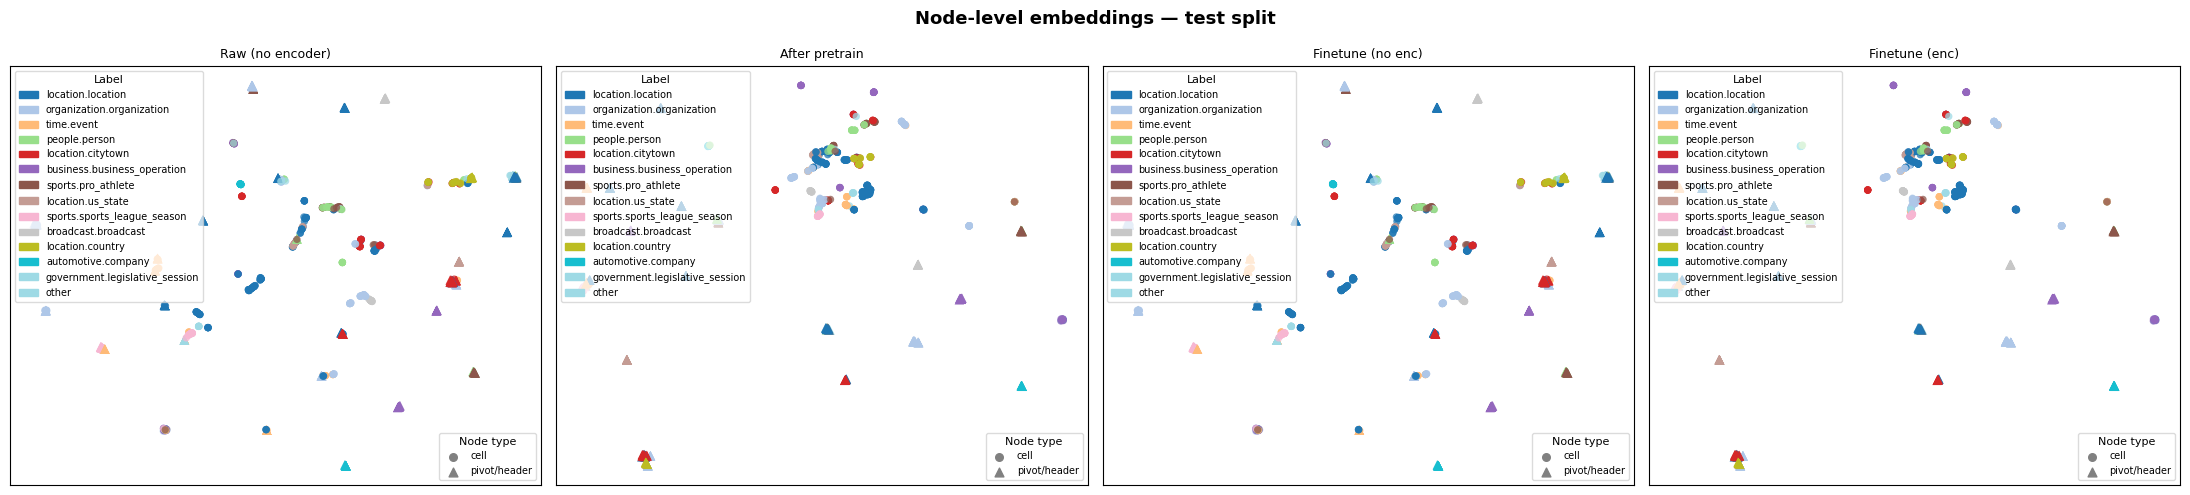

c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[viz] saved → CTA\outputs\embedding_viz\column_embeddings_test.png


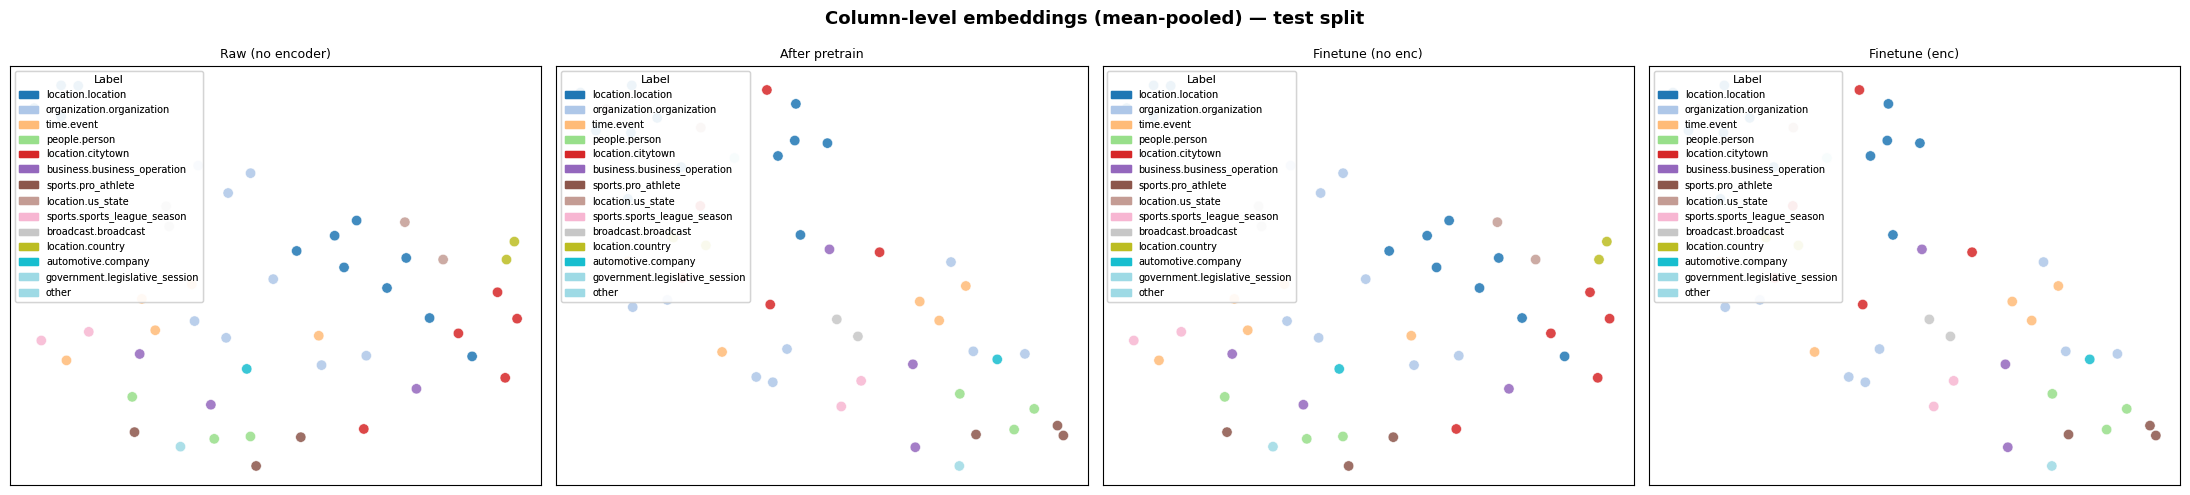

In [6]:
%reload_ext autoreload
%autoreload 2
from pathlib import Path
import re

# ── Resolve checkpoint paths ──────────────────────────────────────────────────
_PT  = str(sorted(Path("checkpoints/dry_run_pretrain").glob("*.ckpt"))[-1]) \
       if list(Path("checkpoints/dry_run_pretrain").glob("*.ckpt")) else ""
_FTE = str(sorted(Path("checkpoints/dry_run_finetune_enc").glob("*.ckpt"))[-1]) \
       if list(Path("checkpoints/dry_run_finetune_enc").glob("*.ckpt")) else ""

# ── Extract data folder from DRY (avoids OmegaConf backslash issues) ─────────
_m = re.search(r"data\.folder=(\S+)", DRY)
_DATA_FOLDER = _m.group(1) if _m else ""

%run visualize_embeddings.py \
    --pretrain_ckpt  {_PT} \
    --ft_enc_ckpt    {_FTE} \
    --data_folder    {_DATA_FOLDER} \
    --split          test \
    --max_records    20 \
    --max_rows       6 \
    --top_k_labels   12


## 5 — Inspect dev / test metric JSON

In [7]:
import json

for split in ("dev", "test"):
    p = Path("CTA/outputs/dry_run_raw") / f"cta_{split}_metrics.json"
    if p.exists():
        print(f"\n── {split} metrics (raw embeddings) ──")
        print(json.dumps(json.loads(p.read_text()), indent=2))
    else:
        print(f"{p} not found")


── dev metrics (raw embeddings) ──
{
  "accuracy": 0.9936704635620117,
  "precision_micro": 0.6666666865348816,
  "recall_micro": 0.19607843458652496,
  "f1_micro": 0.3030303120613098,
  "precision_macro": 0.006593618076294661,
  "recall_macro": 0.005698108114302158,
  "f1_macro": 0.0060648005455732346,
  "threshold": 0.5
}

── test metrics (raw embeddings) ──
{
  "accuracy": 0.9953725337982178,
  "precision_micro": 0.8846153616905212,
  "recall_micro": 0.29113924503326416,
  "f1_micro": 0.43809524178504944,
  "precision_macro": 0.015406163409352303,
  "recall_macro": 0.011251168325543404,
  "f1_macro": 0.012324931100010872,
  "threshold": 0.5
}
